# Сравнение обучения нейронной сети с MSE и BCE

**Авторы:** Ляхов Ярослав, Суворов Степан  
Университет Иннополис

## Цель работы

Нужно сравнить две функции потерь в задаче бинарной классификации:

- MSE;
- Binary Cross-Entropy.

Сеть, данные и оптимизатор остаются одинаковыми. Меняется только loss. Так проще увидеть, как loss влияет на градиенты, скорость обучения и качество.

## Теоретическая часть

Пусть сеть выдает логит $z$. Это сырой выход модели. Он еще не является вероятностью. Вероятность класса `1` получаем через sigmoid:

$$
p = \sigma(z) = \frac{1}{1 + e^{-z}}.
$$

При backpropagation градиент для весов считается по цепному правилу:

$$
\frac{\partial L}{\partial w} =
\frac{\partial L}{\partial z}
\frac{\partial z}{\partial w}.
$$

Значит, loss задает силу сигнала, который идет назад по сети.

### Binary Cross-Entropy

Для бинарной классификации:

$$
L_{BCE}= -y\log p -(1-y)\log(1-p).
$$

Если BCE совмещается с sigmoid, то градиент по логиту простой:

$$
\frac{\partial L_{BCE}}{\partial z}=p-y.
$$

### MSE

Если использовать MSE для вероятности:

$$
L_{MSE}=(p-y)^2,
$$

то градиент по логиту:

$$
\frac{\partial L_{MSE}}{\partial z}=2(p-y)p(1-p).
$$

Главное отличие в множителе $p(1-p)$. Когда sigmoid насыщается, $p$ близко к 0 или 1. Тогда этот множитель мал. Из-за этого MSE может дать слабый градиент даже при большой ошибке.

### Почему дифференцируем loss по логиту `z`

Loss ниже записан через вероятность `p`. Но `p` не живет отдельно. Она получается из логита:

$$
p = \sigma(z).
$$

На самом деле loss зависит от `z` через sigmoid:

$$
L = L(p, y) = L(\sigma(z), y).
$$

поэтому используем цепное правило:

$$
\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial p}
\cdot
\frac{\partial p}{\partial z}.
$$

Для MSE:

$$
L_{MSE} = (p-y)^2.
$$

Значит:

$$
\frac{\partial L_{MSE}}{\partial p} = 2(p-y).
$$

Для sigmoid:

$$
\frac{\partial p}{\partial z} = p(1-p).
$$

В итоге:

$$
\frac{\partial L_{MSE}}{\partial z}
=
2(p-y)p(1-p).
$$

то есть `z` не пропал. Он просто спрятан внутри `p`.

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, f1_score, log_loss, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
print(f"torch: {torch.__version__}")

device: cpu
torch: 2.12.0+cpu


## 1. Сравнение градиентов по логиту

Сначала сравним не все обучение, а только сигнал $\partial L / \partial z$. Именно этот сигнал loss отправляет назад в сеть.

Берем объект класса $y=1$. Если логит $z$ сильно отрицательный, модель ошибается. Вероятность $p$ близка к 0.

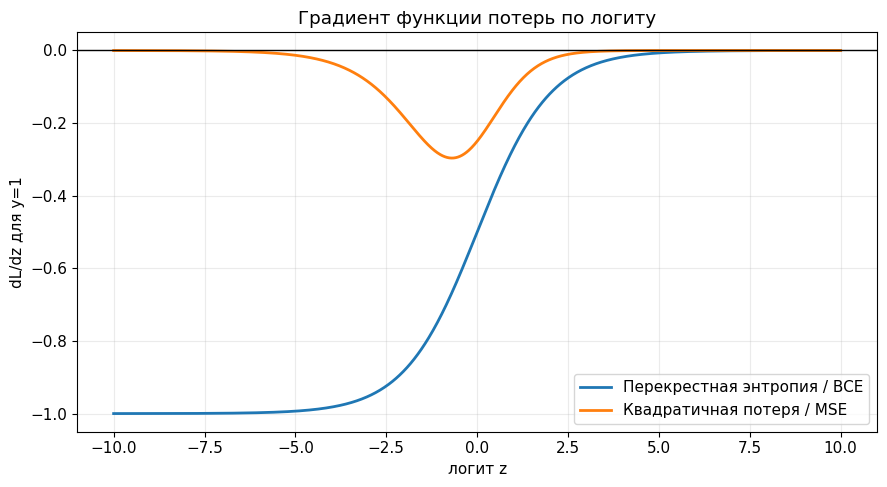

In [2]:
z = torch.linspace(-10, 10, 1000)
p = torch.sigmoid(z)
y = torch.ones_like(p)

grad_bce = p - y
grad_mse = 2 * (p - y) * p * (1 - p)

plt.figure(figsize=(9, 5))
plt.plot(z, grad_bce, label="Перекрестная энтропия / BCE", linewidth=2)
plt.plot(z, grad_mse, label="Квадратичная потеря / MSE", linewidth=2)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("логит z")
plt.ylabel("dL/dz для y=1")
plt.title("Градиент функции потерь по логиту")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/gradient_bce_vs_mse.png", dpi=160)
plt.show()

На графике видно, что при ошибке $z \ll 0$:

- у BCE градиент близок к `-1`, поэтому сигнал остается сильным;
- у MSE градиент близок к `0`, потому что sigmoid насыщена и $p(1-p)$ почти ноль.

это одна из причин, почему BCE часто учит классификатор быстрее.

## 2. Постановка эксперимента

Используем `make_moons`. Это простая задача бинарной классификации. Классы там нельзя хорошо разделить одной прямой, поэтому берем небольшую MLP.

Условия сравнения:

- один train/test split;
- одна архитектура;
- одна инициализация весов;
- один оптимизатор SGD с momentum;
- отличается только loss.

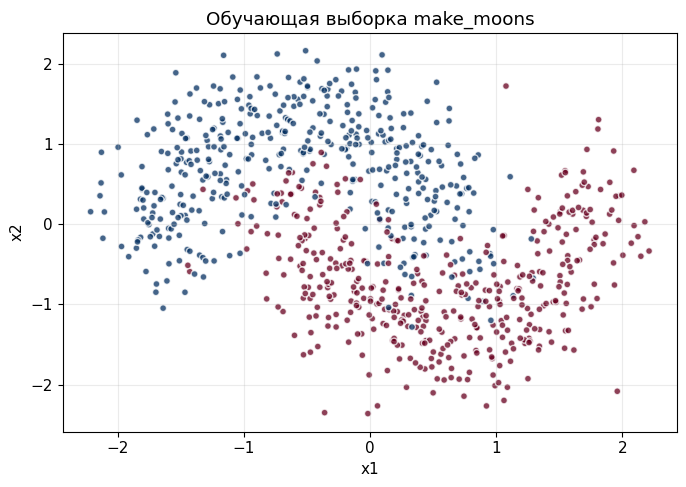

In [3]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=SEED)
X = StandardScaler().fit_transform(X).astype(np.float32)
y = y.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

X_train_t = torch.tensor(X_train, device=device)
y_train_t = torch.tensor(y_train, device=device)
X_test_t = torch.tensor(X_test, device=device)
y_test_t = torch.tensor(y_test, device=device)

plt.figure(figsize=(7, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), cmap="RdBu_r", s=24, alpha=0.75, edgecolor="white")
plt.title("Обучающая выборка make_moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dataset_make_moons.png", dpi=160)
plt.show()

In [4]:
class BinaryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)


def loss_function(name, logits, targets):
    if name == "BCE":
        return F.binary_cross_entropy_with_logits(logits, targets)
    if name == "MSE":
        probs = torch.sigmoid(logits)
        return F.mse_loss(probs, targets)
    raise ValueError(name)


def evaluate(model, X_eval_t=None, y_eval=None):
    if X_eval_t is None:
        X_eval_t = X_test_t
    if y_eval is None:
        y_eval = y_test

    model.eval()
    with torch.no_grad():
        logits = model(X_eval_t)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()

    pred = (probs >= 0.5).astype(int)
    true = y_eval.ravel().astype(int)

    return {
        "accuracy": accuracy_score(true, pred),
        "f1": f1_score(true, pred),
        "log_loss": log_loss(true, np.clip(probs, 1e-7, 1 - 1e-7)),
        "brier_score": mean_squared_error(true, probs),
    }


def train(loss_name, epochs=350, lr=0.05, seed=SEED, track_every=5):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = BinaryMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train_t)
        loss = loss_function(loss_name, logits, y_train_t)
        loss.backward()

        first_layer_grad = model.net[0].weight.grad.detach().norm().item()
        all_grad = torch.sqrt(sum(
            (param.grad.detach() ** 2).sum()
            for param in model.parameters()
            if param.grad is not None
        )).item()

        with torch.no_grad():
            probs_train = torch.sigmoid(logits)
            mean_sigmoid_slope = (probs_train * (1 - probs_train)).mean().item()
            mean_abs_logit = logits.abs().mean().item()

        optimizer.step()

        if epoch % track_every == 0 or epoch == epochs - 1:
            history.append({
                "epoch": epoch,
                "train_loss": loss.item(),
                "grad_norm_first_layer": first_layer_grad,
                "grad_norm_all": all_grad,
                "mean_p_one_minus_p": mean_sigmoid_slope,
                "mean_abs_logit": mean_abs_logit,
                **evaluate(model),
            })

    return model, pd.DataFrame(history)


models = {}
histories = {}
results = {}

for loss_name in ["BCE", "MSE"]:
    model, hist = train(loss_name)
    models[loss_name] = model
    histories[loss_name] = hist
    results[loss_name] = evaluate(model)

pd.DataFrame(results).T

,accuracy,f1,log_loss,brier_score
BCE,0.944444,0.943503,0.149560,0.042632
MSE,0.891667,0.888889,0.296625,0.088968


## 3. Графики обучения

Ниже показаны:

- train loss;
- accuracy на test;
- F1-score на test;
- норма градиента первого слоя.

Градиент первого слоя показывает, насколько сильный сигнал доходит до ранних весов.

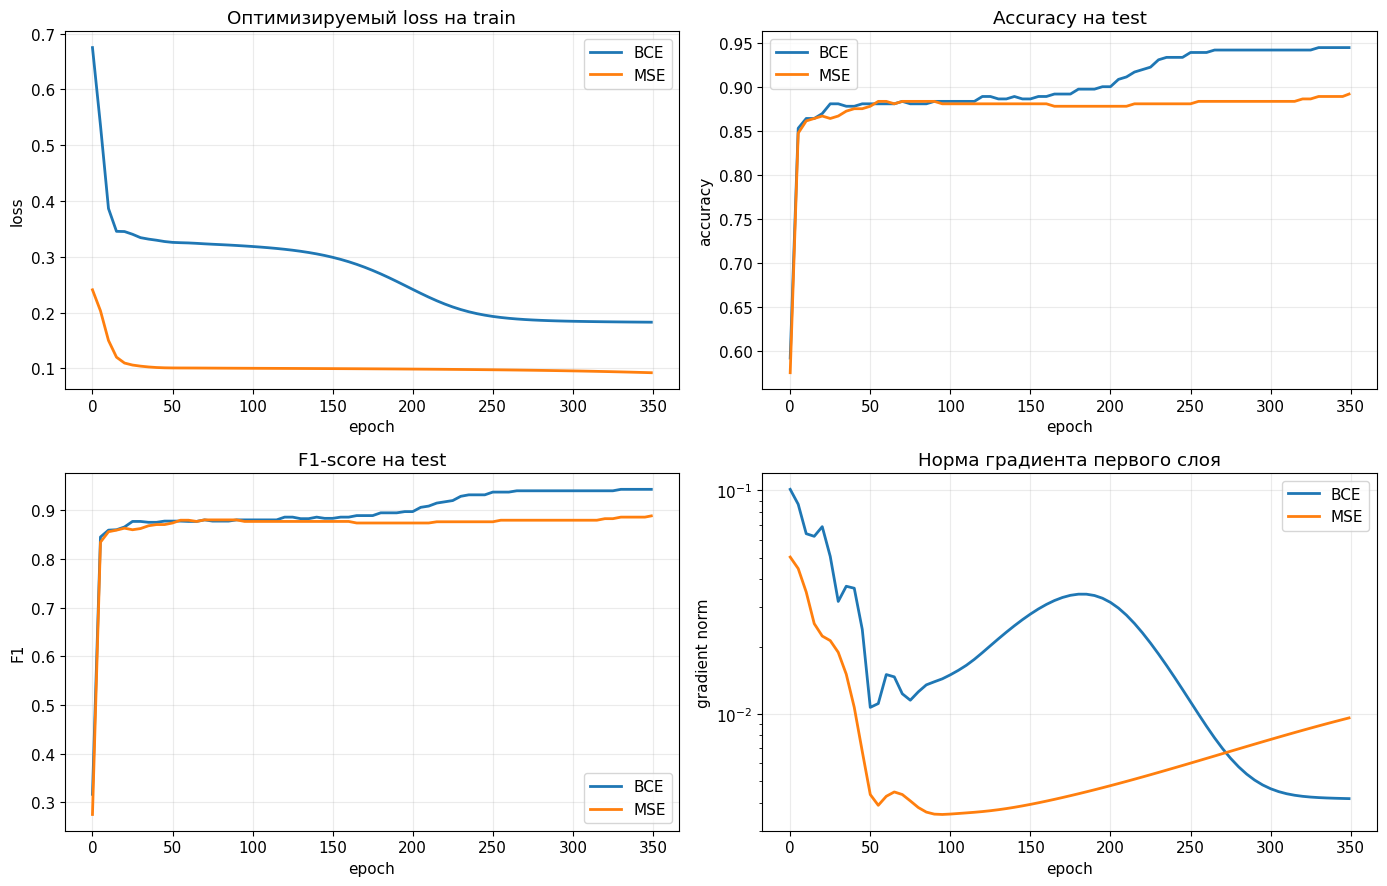

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for loss_name, hist in histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], label=loss_name, linewidth=2)
    axes[1].plot(hist["epoch"], hist["accuracy"], label=loss_name, linewidth=2)
    axes[2].plot(hist["epoch"], hist["f1"], label=loss_name, linewidth=2)
    axes[3].plot(hist["epoch"], hist["grad_norm_first_layer"], label=loss_name, linewidth=2)

axes[0].set_title("Оптимизируемый loss на train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")

axes[1].set_title("Accuracy на test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")

axes[2].set_title("F1-score на test")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("F1")

axes[3].set_title("Норма градиента первого слоя")
axes[3].set_xlabel("epoch")
axes[3].set_ylabel("gradient norm")
axes[3].set_yscale("log")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_bce_vs_mse.png", dpi=160)
plt.show()

### Динамика насыщения sigmoid и скорость

У MSE в градиенте есть $p(1-p)$. Поэтому полезно посмотреть, как этот множитель меняется во время обучения. Если среднее $p(1-p)$ маленькое, sigmoid ближе к насыщению. Тогда сигнал MSE по логиту слабее.

,epoch_to_accuracy_0.90,final_accuracy,final_f1,final_mean_p_one_minus_p
BCE,195.0,0.944444,0.943503,0.056561
MSE,NaN,0.891667,0.888889,0.108099


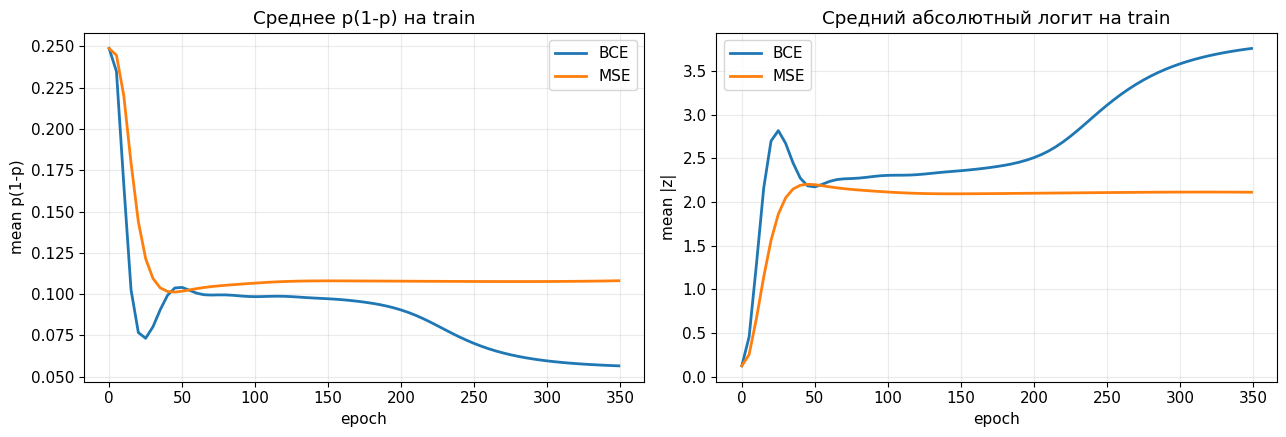

In [6]:
def first_epoch_at(hist, metric="accuracy", threshold=0.90):
    reached = hist.loc[hist[metric] >= threshold, "epoch"]
    return np.nan if reached.empty else int(reached.iloc[0])

convergence = pd.DataFrame({
    loss_name: {
        "epoch_to_accuracy_0.90": first_epoch_at(hist),
        "final_accuracy": hist["accuracy"].iloc[-1],
        "final_f1": hist["f1"].iloc[-1],
        "final_mean_p_one_minus_p": hist["mean_p_one_minus_p"].iloc[-1],
    }
    for loss_name, hist in histories.items()
}).T

display(convergence)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for loss_name, hist in histories.items():
    axes[0].plot(hist["epoch"], hist["mean_p_one_minus_p"], label=loss_name, linewidth=2)
    axes[1].plot(hist["epoch"], hist["mean_abs_logit"], label=loss_name, linewidth=2)

axes[0].set_title("Среднее p(1-p) на train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("mean p(1-p)")
axes[1].set_title("Средний абсолютный логит на train")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean |z|")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sigmoid_saturation_bce_vs_mse.png", dpi=160)
plt.show()

## 4. Границы классификации

Следующий график показывает, где каждая сеть относит точки к классу `1`.

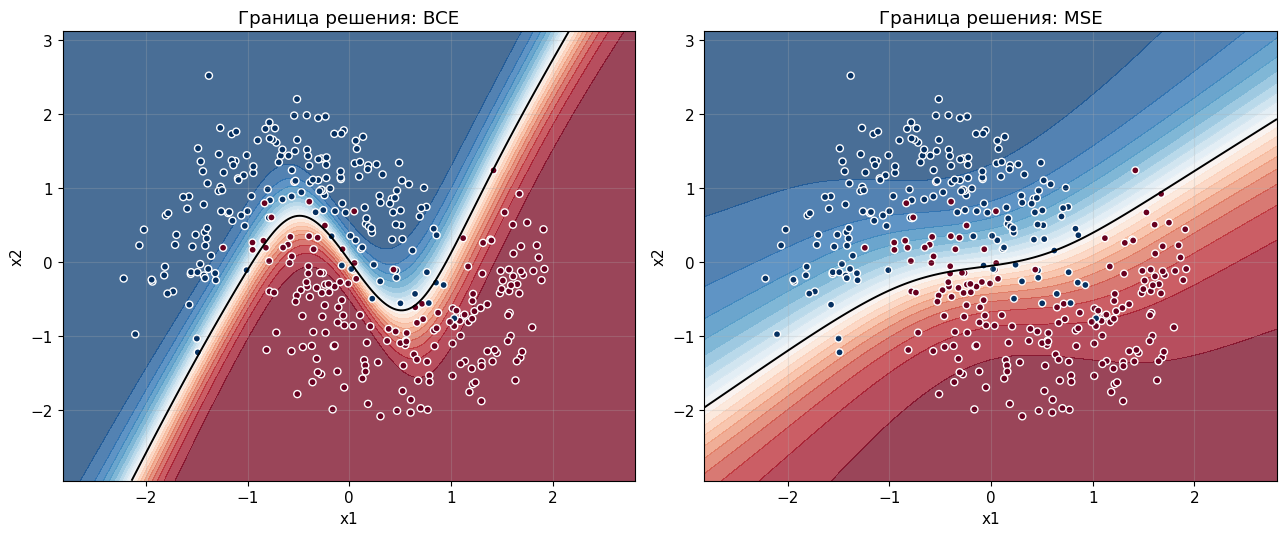

In [7]:
def plot_decision_boundaries(models):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_t = torch.tensor(grid, device=device)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    for ax, (loss_name, model) in zip(axes, models.items()):
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(grid_t)).cpu().numpy().reshape(xx.shape)

        ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.75)
        ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=1.4)
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test.ravel(), cmap="RdBu_r", edgecolor="white", s=26)
        ax.set_title(f"Граница решения: {loss_name}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/decision_boundaries_bce_vs_mse.png", dpi=160)
    plt.show()


plot_decision_boundaries(models)

## 5. Итоговая таблица

В таблице сравниваются финальные метрики на test.

`log_loss` и `brier_score` здесь считаются как метрики качества вероятностей. Это не обязательно тот loss, который оптимизировался при обучении.

In [8]:
summary = pd.DataFrame(results).T
summary.index.name = "training_loss"
summary

,accuracy,f1,log_loss,brier_score
training_loss,,,,
BCE,0.944444,0.943503,0.149560,0.042632
MSE,0.891667,0.888889,0.296625,0.088968


## Вывод по базовому эксперименту

В базовом эксперименте `lr=0.05` одинаковый для BCE и MSE. BCE дает более сильный сигнал и быстрее выходит на хорошую accuracy/F1. Это совпадает с формулами: у BCE есть член $p-y$, а у MSE еще есть множитель $p(1-p)$.

но это не доказывает, что MSE всегда хуже. У MSE масштаб градиентов меньше. Значит, ей может быть нужен другой learning rate. Поэтому ниже есть запуски на разных seed и отдельный подбор learning rate.

## Связь с исходной статьей

В `project_base.pdf` loss рассматривается как то, что модель оптимизирует при обучении. Метрики нужны уже для оценки результата. В этой работе эта идея проверяется на классификации. Одна и та же сеть учится с разными loss. Потом сравниваются метрики и градиенты.

## 6. Множественные запуски при фиксированном learning rate

Повторим обучение 20 раз с разной инициализацией. Данные, train/test split, архитектура и оптимизатор те же. Learning rate пока один и тот же: `lr=0.05`.

In [9]:
def train_with_seed(loss_name, seed, epochs=1000, lr=0.05, target_accuracy=0.90):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = BinaryMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    epoch_to_target = np.nan

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = loss_function(loss_name, logits, y_train_t)
        loss.backward()
        optimizer.step()

        if np.isnan(epoch_to_target) and (epoch % 10 == 0 or epoch == epochs - 1):
            if evaluate(model)["accuracy"] >= target_accuracy:
                epoch_to_target = epoch

    metrics = evaluate(model)
    metrics["epoch_to_accuracy_0.90"] = epoch_to_target
    return metrics


seeds = list(range(20))
fixed_lr_records = []

for loss_name in ["BCE", "MSE"]:
    for seed in seeds:
        metrics = train_with_seed(loss_name, seed, lr=0.05)
        fixed_lr_records.append({"loss": loss_name, "seed": seed, **metrics})

fixed_lr_df = pd.DataFrame(fixed_lr_records)
fixed_lr_df.head()

,loss,seed,accuracy,f1,log_loss,brier_score,epoch_to_accuracy_0.90
0,BCE,0,0.950000,0.949721,0.135058,0.037612,170.0
1,BCE,1,0.950000,0.949438,0.134664,0.037303,200.0
2,BCE,2,0.941667,0.940510,0.142708,0.040610,180.0
3,BCE,3,0.950000,0.949721,0.135630,0.037644,170.0
4,BCE,4,0.952778,0.952381,0.134348,0.037237,170.0


### Результаты множественных запусков

Ниже среднее и стандартное отклонение по 20 запускам. Для `accuracy` и `f1` больше значит лучше. Для `log_loss`, `brier_score` и `epoch_to_accuracy_0.90` меньше значит лучше.

In [10]:
def summarize_runs(df):
    return (
        df.groupby("loss")[["accuracy", "f1", "log_loss", "brier_score", "epoch_to_accuracy_0.90"]]
        .agg(["mean", "std"])
        .round(4)
    )

fixed_lr_summary = summarize_runs(fixed_lr_df)
fixed_lr_summary

accuracy              f1         log_loss         brier_score          \
         mean     std    mean     std     mean     std        mean     std   
loss                                                                         
BCE    0.9487  0.0045  0.9482  0.0048   0.1363  0.0031      0.0381  0.0013   
MSE    0.9408  0.0144  0.9397  0.0150   0.1610  0.0351      0.0448  0.0118   

     epoch_to_accuracy_0.90           
                       mean      std  
loss                                  
BCE                184.5000  56.4265  
MSE                436.3158  92.6289

### Парное сравнение по seed

Для каждого seed обучаются обе модели. Поэтому сравниваем пары BCE и MSE на одном и том же seed.

In [11]:
def paired_comparison(df):
    rows = []
    wide = df.pivot(index="seed", columns="loss")

    metric_specs = {
        "accuracy": "higher",
        "f1": "higher",
        "log_loss": "lower",
        "brier_score": "lower",
        "epoch_to_accuracy_0.90": "lower",
    }

    for metric, direction in metric_specs.items():
        bce = wide[metric]["BCE"]
        mse = wide[metric]["MSE"]
        advantage = bce - mse if direction == "higher" else mse - bce
        t_stat, p_value = stats.ttest_rel(bce, mse, nan_policy="omit")
        rows.append({
            "metric": metric,
            "better_direction": direction,
            "mean_BCE_advantage": advantage.mean(),
            "std_advantage": advantage.std(),
            "BCE_wins": int((advantage > 0).sum()),
            "ties": int((advantage == 0).sum()),
            "p_value_paired_ttest": p_value,
        })

    return pd.DataFrame(rows).round(5)


paired_fixed_lr = paired_comparison(fixed_lr_df)
paired_fixed_lr

,metric,better_direction,mean_BCE_advantage,std_advantage,BCE_wins,ties,p_value_paired_ttest
0,accuracy,higher,0.00792,0.01322,17,1,0.01490
1,f1,higher,0.00855,0.01376,17,0,0.01196
2,log_loss,lower,0.02476,0.03390,20,0,0.00407
3,brier_score,lower,0.00674,0.01131,20,0,0.01533
4,epoch_to_accuracy_0.90,lower,262.10526,60.33047,19,0,0.00000


## 7. Подбор learning rate

Одинаковый `lr=0.05` полезен для первого сравнения. Но это не совсем честно для итогового качества. У MSE градиенты меньше, и ей может подойти другой шаг. Поэтому делаем небольшой sweep по learning rate. Лучший `lr` выбираем по validation split. Test остается для финальной проверки.

In [12]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train
)

X_fit_t = torch.tensor(X_fit, device=device)
y_fit_t = torch.tensor(y_fit, device=device)
X_val_t = torch.tensor(X_val, device=device)


def train_on_split(loss_name, lr, seed, epochs, X_fit_t, y_fit_t):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = BinaryMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_fit_t)
        loss = loss_function(loss_name, logits, y_fit_t)
        loss.backward()
        optimizer.step()

    return model


lr_grid = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
lr_records = []

for loss_name in ["BCE", "MSE"]:
    for lr in lr_grid:
        for seed in range(5):
            model = train_on_split(loss_name, lr, seed, epochs=500, X_fit_t=X_fit_t, y_fit_t=y_fit_t)
            metrics = evaluate(model, X_val_t, y_val)
            lr_records.append({"loss": loss_name, "lr": lr, "seed": seed, **metrics})

lr_df = pd.DataFrame(lr_records)
lr_summary = (
    lr_df.groupby(["loss", "lr"])[["accuracy", "f1", "log_loss", "brier_score"]]
    .agg(["mean", "std"])
    .round(4)
)
lr_summary

accuracy              f1         log_loss         brier_score  \
               mean     std    mean     std     mean     std        mean   
loss lr                                                                    
BCE  0.005   0.8695  0.0026  0.8666  0.0023   0.3163  0.0022      0.0964   
     0.010   0.8743  0.0072  0.8709  0.0065   0.3028  0.0076      0.0919   
     0.020   0.9152  0.0071  0.9151  0.0077   0.2058  0.0270      0.0600   
     0.050   0.9286  0.0067  0.9292  0.0066   0.1678  0.0080      0.0507   
     0.100   0.9314  0.0043  0.9318  0.0043   0.1584  0.0094      0.0479   
     0.200   0.9343  0.0021  0.9350  0.0022   0.1660  0.0136      0.0475   
     0.500   0.9352  0.0043  0.9361  0.0048   0.1844  0.0172      0.0482   
     1.000   0.9229  0.0071  0.9239  0.0070   0.2028  0.0181      0.0519   
MSE  0.005   0.8629  0.0103  0.8608  0.0090   0.3320  0.0050      0.1000   
     0.010   0.8695  0.0026  0.8666  0.0023   0.3228  0.0024      0.0977   
     0.020   0.8695  0.0026  0.8666  0.0023   0.3164  0.0036      0.0956   
     0.050   0.9114  0.0064  0.9099  0.0069   0.2350  0.0216      0.0656   
     0.100   0.9257  0.0026  0.9265  0.0028   0.1815  0.0061      0.0542   
     0.200   0.9286  0.0048  0.9292  0.0047   0.1728  0.0076      0.0517   
     0.500   0.9343  0.0021  0.9348  0.0020   0.1673  0.0059      0.0490   
     1.000   0.9333  0.0034  0.9340  0.0036   0.1685  0.0059      0.0493   

                    
               std  
loss lr             
BCE  0.005  0.0011  
     0.010  0.0031  
     0.020  0.0084  
     0.050  0.0023  
     0.100  0.0025  
     0.200  0.0017  
     0.500  0.0013  
     1.000  0.0020  
MSE  0.005  0.0017  
     0.010  0.0011  
     0.020  0.0016  
     0.050  0.0074  
     0.100  0.0018  
     0.200  0.0027  
     0.500  0.0012  
     1.000  0.0009

In [13]:
lr_choice_table = (
    lr_df.groupby(["loss", "lr"])[["accuracy", "f1", "log_loss", "brier_score"]]
    .mean()
    .reset_index()
    .sort_values(["loss", "accuracy", "f1", "log_loss"], ascending=[True, False, False, True])
)

best_lr_by_loss = lr_choice_table.groupby("loss").head(1).set_index("loss")["lr"].to_dict()
lr_choice_table.groupby("loss").head(3).round(4)

,loss,lr,accuracy,f1,log_loss,brier_score
6,BCE,0.5,0.9352,0.9361,0.1844,0.0482
5,BCE,0.2,0.9343,0.9350,0.1660,0.0475
4,BCE,0.1,0.9314,0.9318,0.1584,0.0479
14,MSE,0.5,0.9343,0.9348,0.1673,0.0490
15,MSE,1.0,0.9333,0.9340,0.1685,0.0493
13,MSE,0.2,0.9286,0.9292,0.1728,0.0517


## 8. Финальное сравнение с выбранным learning rate

Теперь обучаем модели на train и проверяем на test. Для каждого loss берем learning rate, выбранный на validation.

In [14]:
tuned_records = []

for loss_name in ["BCE", "MSE"]:
    chosen_lr = best_lr_by_loss[loss_name]
    for seed in seeds:
        metrics = train_with_seed(loss_name, seed, epochs=1000, lr=chosen_lr)
        tuned_records.append({"loss": loss_name, "seed": seed, "lr": chosen_lr, **metrics})

tuned_df = pd.DataFrame(tuned_records)
summarize_runs(tuned_df)

accuracy              f1         log_loss         brier_score          \
         mean     std    mean     std     mean     std        mean     std   
loss                                                                         
BCE    0.9482  0.0042  0.9473  0.0043   0.1808  0.0108      0.0431  0.0024   
MSE    0.9474  0.0044  0.9467  0.0046   0.1379  0.0013      0.0378  0.0004   

     epoch_to_accuracy_0.90           
                       mean      std  
loss                                  
BCE                    33.0  10.3110  
MSE                    62.0  17.3509

In [15]:
paired_tuned = paired_comparison(tuned_df)
paired_tuned

,metric,better_direction,mean_BCE_advantage,std_advantage,BCE_wins,ties,p_value_paired_ttest
0,accuracy,higher,0.00083,0.00681,8,4,0.59058
1,f1,higher,0.00063,0.00714,9,0,0.69669
2,log_loss,lower,-0.04290,0.01016,0,0,0.00000
3,brier_score,lower,-0.00529,0.00229,0,0,0.00000
4,epoch_to_accuracy_0.90,lower,29.00000,9.67906,20,0,0.00000


## Итоговый вывод

Теория подтверждается. BCE дает более прямой градиент по логиту. При одинаковом `lr` она быстрее выходит на хорошее качество. Это видно по графикам, по скорости достижения accuracy 0.90 и по 20 запускам при `lr=0.05`.

После подбора learning rate вывод мягче. MSE почти догоняет BCE по `accuracy` и `f1`. В этом запуске MSE даже дает меньшие `log_loss` и `brier_score` на test. Но BCE все равно быстрее достигает accuracy 0.90.

итог такой: BCE лучше подходит для бинарной классификации с логитами. MSE тоже может обучить модель, если подобрать шаг. Но ее градиент через sigmoid слабее, поэтому с ней легче получить медленное обучение.